# SN Ia Intrinsic Scatter Demo

This notebook demonstrates the three intrinsic scatter models available in lightcurvelynx:
- **COH** — coherent (gray) scatter: same magnitude offset at all wavelengths
- **G10** — Guy et al. (2010) chromatic scatter derived from SALT2 color dispersion
- **C11** — Chotard et al. (2011) correlated scatter across six photometric bands

We build a SALT3 simulation using `SncosmoWrapperModel`, attach each scatter model as a
rest-frame effect via `add_effect()`, and measure the resulting magnitude scatter in
restframe Bessell U, B, V, R, I bands.

In [1]:
import numpy as np
import sncosmo
import matplotlib.pyplot as plt

from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.effects.snia_intrinsic_scatter import SNIaIntrinsicScatter

## 2. Build baseline SALT3 model

We use a canonical SN Ia at z = 0 (restframe) with parameters
x₁ = 0, c = 0. The baseline SED at peak (phase = 0) is evaluated without any scatter.

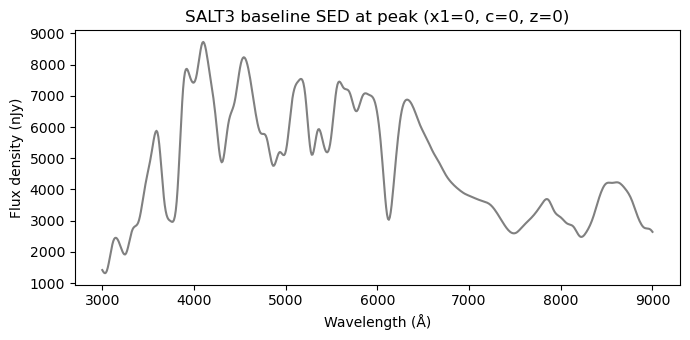

In [2]:
# Fixed SALT3 parameters — isolates the scatter effect from parameter variation
SALT3_KWARGS = dict(t0=0.0, x0=3e-5, x1=0.0, c=0.0, redshift=0.0)

# Wavelength grid covering Bessell U–I (3000–9000 Å)
wavelengths = np.linspace(3000, 9000, 600)
times_peak = np.array([0.0])  # observer-frame MJD at peak (= t0)

baseline_model = SncosmoWrapperModel("salt3", **SALT3_KWARGS)
state = baseline_model.sample_parameters()
baseline_sed = baseline_model.evaluate_sed(times_peak, wavelengths, state)  # (1, N) nJy

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wavelengths, baseline_sed[0], color="gray")
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux density (nJy)")
ax.set_title("SALT3 baseline SED at peak (x1=0, c=0, z=0)")
plt.tight_layout()

## 4. Simulate scatter realizations

For each scatter model we:
1. Create a new `SncosmoWrapperModel` with the same fixed SALT3 parameters
2. Attach `SNIaIntrinsicScatter` as a rest-frame effect via `add_effect()`
3. Sample N states at once with `model.sample_parameters(N)` and iterate through them
4. Compute Δmag = −2.5 log₁₀(F_scattered / F_baseline) per band

In [3]:
from lightcurvelynx.astro_utils.passbands import Passband, PassbandGroup

BANDS = {"U": "bessellux", "B": "bessellb", "V": "bessellv", "R": "bessellr", "I": "besselli"}

# Build PassbandGroup from sncosmo Bessell filters
passbands = PassbandGroup([
    Passband.from_sncosmo("bessell", filter_name, bandpass=bandname)
    for filter_name, bandname in BANDS.items()
])

# Baseline band fluxes via sncosmo (for display)
baseline_flux = {
    filter_name: baseline_model.source.bandflux(bandname, 0.0, zp=25.0, zpsys="ab")
    for filter_name, bandname in BANDS.items()
}
print("Baseline band fluxes (sncosmo, zp=25 AB):")
for b, f in baseline_flux.items():
    print(f"  Bessell {b}: {f:.4e}")

# Baseline integrals via evaluate_bandfluxes (for ratio)
times_bands = np.repeat(times_peak, len(BANDS))
filters_bands = np.array(list(BANDS.keys()))
baseline_arr = baseline_model.evaluate_bandfluxes(passbands, times_bands, filters_bands, state)
baseline_bandflux = {f"bessell_{f}": v for f, v in zip(BANDS.keys(), baseline_arr)}

N = 300

SCATTER_MODELS = {
    "COH (σ=0.1)": {"modelname": "COH", "sigma": 0.1},
    "G10": {"modelname": "G10", "coh_sigma": 0.09},
    "C11": {"modelname": "C11"},
}

delta_mag = {}  # delta_mag[label][band] = (N,) array

for label, modelpars in SCATTER_MODELS.items():
    effect = SNIaIntrinsicScatter(modelpars=modelpars)
    model = SncosmoWrapperModel("salt3", **SALT3_KWARGS)
    model.add_effect(effect)  # rest_frame=True by default

    states = model.sample_parameters(num_samples=N)

    dm = {b: np.empty(N) for b in BANDS}
    for i, state_i in enumerate(states):
        band_fluxes_arr = model.evaluate_bandfluxes(passbands, times_bands, filters_bands, state_i)
        for j, filter_name in enumerate(BANDS):
            full_name = f"bessell_{filter_name}"
            dm[filter_name][i] = -2.5 * np.log10(band_fluxes_arr[j] / baseline_bandflux[full_name])
    delta_mag[label] = dm
    print(f"{label}: done")

Baseline band fluxes (sncosmo, zp=25 AB):
  Bessell U: 1.1499e+01
  Bessell B: 1.8732e+01
  Bessell V: 1.7261e+01
  Bessell R: 1.4444e+01
  Bessell I: 8.8713e+00
COH (σ=0.1): done


G10: done


C11: done


## 5. Magnitude scatter vs central wavelength

For each model, plot the rms scatter σ(Δmag) against the flux-weighted central
wavelength of each Bessell band. COH (gray) should be flat; G10 and C11 should
decline toward redder bands.

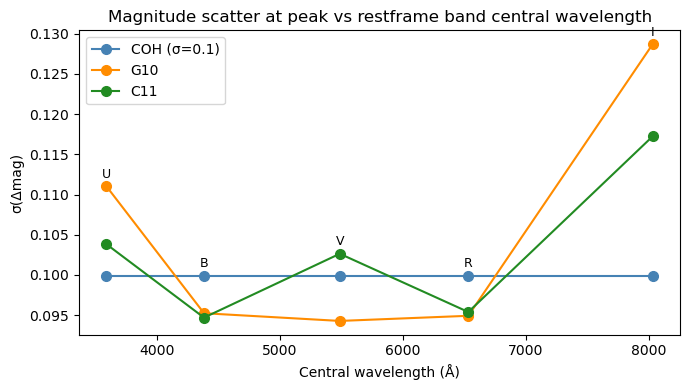

In [4]:
COLORS = {"COH (σ=0.1)": "steelblue", "G10": "darkorange", "C11": "forestgreen"}

central_wave = {
    filter_name: sncosmo.get_bandpass(bandname).wave_eff
    for filter_name, bandname in BANDS.items()
}
band_names = list(BANDS.keys())
x = np.array([central_wave[b] for b in band_names])

fig, ax = plt.subplots(figsize=(7, 4))
all_sigma = {}
for label, dm in delta_mag.items():
    sigma = np.array([dm[b].std() for b in band_names])
    all_sigma[label] = sigma
    ax.plot(x, sigma, "o-", color=COLORS[label], label=label, markersize=7)

# Annotate band names just above the highest σ point in each column
top_sigma = np.max(list(all_sigma.values()), axis=0)
for b, xb, yt in zip(band_names, x, top_sigma):
    ax.annotate(b, xy=(xb, yt), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xlabel("Central wavelength (Å)")
ax.set_ylabel("σ(Δmag)")
ax.set_title("Magnitude scatter at peak vs restframe band central wavelength")
ax.legend()
plt.tight_layout()

## 6. Interpolation method comparison (G10)

We compare four interpolation methods on the G10 model:
- **sine** — SNANA reference: zero derivative at each node, bounded
- **linear** — piecewise linear baseline
- **pchip** — monotone-preserving cubic Hermite: no overshoot, natural slopes at nodes
- **cubic** — C² cubic spline: maximally smooth, but can overshoot between nodes

First we show the scatter function λ → Δmag for a single SN realization,
then the rms σ per band over N realizations.

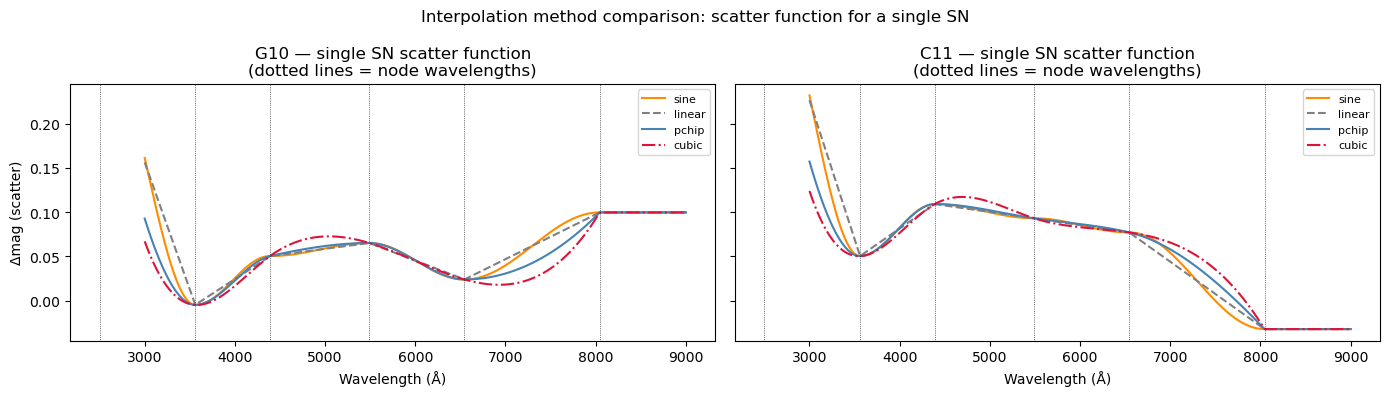

In [5]:
INTERP_METHODS = ["sine", "linear", "pchip", "cubic"]
INTERP_COLORS = {"sine": "darkorange", "linear": "gray", "pchip": "steelblue", "cubic": "crimson"}
INTERP_STYLES = {"sine": "-", "linear": "--", "pchip": "-", "cubic": "-."}

g10_modelpars = {"modelname": "G10", "coh_sigma": 0.09}
c11_modelpars = {"modelname": "C11"}

# --- Single-SN scatter function ---
# Reset to the same seed for each method so node draws are identical —
# differences come purely from the interpolation shape.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (label, modelpars) in zip(axes, [("G10", g10_modelpars), ("C11", c11_modelpars)]):
    for method in INTERP_METHODS:
        effect = SNIaIntrinsicScatter(modelpars=modelpars, interp_method=method)
        model = SncosmoWrapperModel("salt3", **SALT3_KWARGS)
        model.add_effect(effect)
        state_i = next(iter(model.sample_parameters(num_samples=1, rng_info=np.random.default_rng(42))))
        sed = model.evaluate_sed(times_peak, wavelengths, state_i)
        scatter_fn = -2.5 * np.log10(sed[0] / baseline_sed[0])
        ax.plot(wavelengths, scatter_fn, color=INTERP_COLORS[method],
                ls=INTERP_STYLES[method], label=method, lw=1.5)
    for lam in [2500, 3560, 4390, 5490, 6545, 8045]:
        ax.axvline(lam, color="k", lw=0.5, ls=":")
    ax.set_xlabel("Wavelength (Å)")
    ax.set_title(f"{label} — single SN scatter function\n(dotted lines = node wavelengths)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Δmag (scatter)")
fig.suptitle("Interpolation method comparison: scatter function for a single SN")
plt.tight_layout()

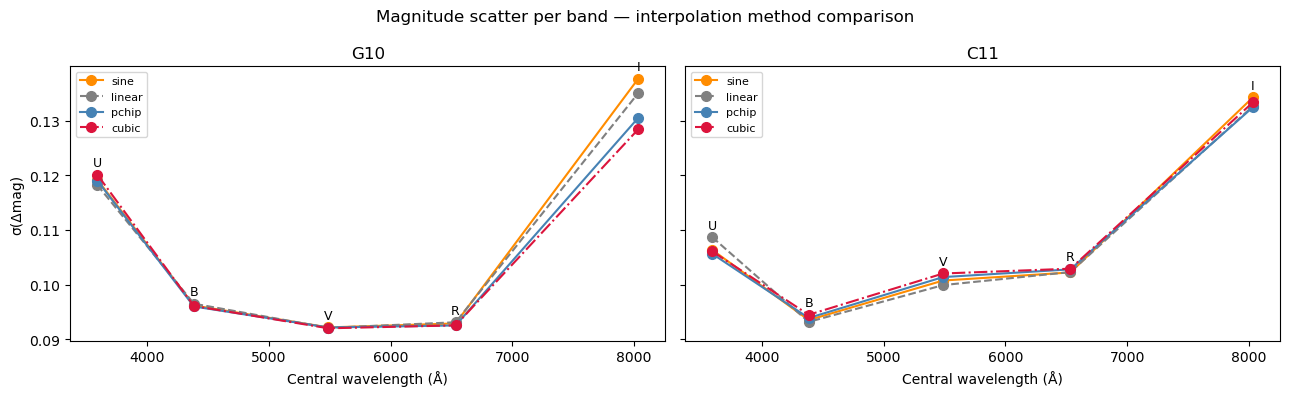

In [6]:
# --- σ per band for each interpolation method ---
# Same seed across methods so each gets identical scatter draws —
# σ differences reflect interpolation shape only, not sampling noise.
delta_mag_interp = {}

for scatter_label, modelpars in [("G10", g10_modelpars), ("C11", c11_modelpars)]:
    delta_mag_interp[scatter_label] = {}
    for method in INTERP_METHODS:
        effect = SNIaIntrinsicScatter(modelpars=modelpars, interp_method=method)
        model = SncosmoWrapperModel("salt3", **SALT3_KWARGS)
        model.add_effect(effect)
        states = model.sample_parameters(num_samples=N, rng_info=np.random.default_rng(42))

        dm = {b: np.empty(N) for b in BANDS}
        for i, state_i in enumerate(states):
            band_fluxes_arr = model.evaluate_bandfluxes(passbands, times_bands, filters_bands, state_i)
            for j, filter_name in enumerate(BANDS):
                full_name = f"bessell_{filter_name}"
                dm[filter_name][i] = -2.5 * np.log10(band_fluxes_arr[j] / baseline_bandflux[full_name])
        delta_mag_interp[scatter_label][method] = dm

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, scatter_label in zip(axes, ["G10", "C11"]):
    for method in INTERP_METHODS:
        sigma = np.array([delta_mag_interp[scatter_label][method][b].std() for b in band_names])
        ax.plot(x, sigma, "o" + INTERP_STYLES[method], color=INTERP_COLORS[method],
                label=method, markersize=7)
    top_sigma = np.max([np.array([delta_mag_interp[scatter_label][m][b].std() for b in band_names])
                        for m in INTERP_METHODS], axis=0)
    for b, xb, yt in zip(band_names, x, top_sigma):
        ax.annotate(b, xy=(xb, yt), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=9)
    ax.set_xlabel("Central wavelength (Å)")
    ax.set_title(f"{scatter_label}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("σ(Δmag)")
fig.suptitle("Magnitude scatter per band — interpolation method comparison")
plt.tight_layout()